the below code equally partitions no tumor and then sets alpha as 1



In [1]:
import os
import random
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Subset, random_split


# ---- CONFIG ----
ROOT = "/Users/ishabhansali/Downloads/resnet_project/cleaned"
TRAIN_DIR = os.path.join(ROOT, "Training")
TEST_DIR = os.path.join(ROOT, "Testing")
NUM_CLIENTS = 4
LOCAL_TEST_FRAC = 0.2
SEED = 77
ALPHA = 0.3  # Moderate non-IID
BATCH_SIZE_MOD = 32

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# ---- PATH CHECKS ----
if not os.path.exists(ROOT):
    raise FileNotFoundError(f"ROOT folder not found: {ROOT}")
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Training directory not found: {TRAIN_DIR}")
if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Testing directory not found: {TEST_DIR}")

# ---- TRANSFORM AND LOAD ----
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

print("Creating global holdout (test) loader for moderate non-IID setup...")
holdout_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_MOD,
    shuffle=False,
    num_workers=0
)
print("Global holdout samples:", len(test_dataset))

# ---- MODERATE NON-IID PARTITION (DIRICHLET) ----
labels = np.array([sample[1] for sample in train_dataset])
num_classes = len(train_dataset.classes)
class_indices = [np.where(labels == i)[0] for i in range(num_classes)]

client_indices = [[] for _ in range(NUM_CLIENTS)]
np.random.seed(SEED)

for c, idxs in enumerate(class_indices):
    # Sample proportions for each client using Dirichlet
    proportions = np.random.dirichlet(np.repeat(ALPHA, NUM_CLIENTS))
    # Adjust for rounding errors
    proportions = (np.cumsum(proportions) * len(idxs)).astype(int)[:-1]
    split_idxs = np.split(np.random.permutation(idxs), proportions)
    for client, idx in enumerate(split_idxs):
        client_indices[client].extend(idx)

# Shuffle indices for each client, then create subsets
client_subsets = []
for indices in client_indices:
    indices = np.array(indices)
    np.random.shuffle(indices)
    subset = torch.utils.data.Subset(train_dataset, indices.tolist())
    client_subsets.append(subset)
    print(f"Client {len(client_subsets)-1} train samples: {len(subset)}")

# ---- TEST SPLIT FOR EACH CLIENT ----
client_data = []
for c in client_subsets:
    n_test = int(len(c) * LOCAL_TEST_FRAC)
    n_train = len(c) - n_test
    tr, te = random_split(c, [n_train, n_test], generator=torch.Generator().manual_seed(SEED))
    client_data.append((tr, te))
    print(f"Client train: {n_train}, test: {n_test}")

# ---- CLASS BREAKDOWN FOR EACH CLIENT ----
class_names = train_dataset.classes
for idx, (client_train, _) in enumerate(client_data):
    labels = [client_train[i][1] for i in range(len(client_train))]
    counts = {class_name: labels.count(i) for i, class_name in enumerate(class_names)}
    print(f"Client {idx}:")
    for class_name in class_names:
        print(f"  {class_name}: {counts[class_name]} samples")
    print("-" * 30)
for idx, (client_train, client_test) in enumerate(client_data):
    # Train split breakdown
    train_labels = [client_train[i][1] for i in range(len(client_train))]
    train_counts = {class_name: train_labels.count(i) for i, class_name in enumerate(class_names)}

    # Test split breakdown
    test_labels = [client_test[i][1] for i in range(len(client_test))]
    test_counts = {class_name: test_labels.count(i) for i, class_name in enumerate(class_names)}

    print(f"Client {idx}:")
    print("  Training set:")
    for class_name in class_names:
        print(f"    {class_name}: {train_counts[class_name]} samples")
    print("  Testing set:")
    for class_name in class_names:
        print(f"    {class_name}: {test_counts[class_name]} samples")
    print("-" * 30)



Train samples: 5712, Test samples: 1311
Creating global holdout (test) loader for moderate non-IID setup...
Global holdout samples: 1311
Client 0 train samples: 1559
Client 1 train samples: 658
Client 2 train samples: 227
Client 3 train samples: 3268
Client train: 1248, test: 311
Client train: 527, test: 131
Client train: 182, test: 45
Client train: 2615, test: 653
Client 0:
  glioma: 1036 samples
  meningioma: 129 samples
  notumor: 83 samples
  pituitary: 0 samples
------------------------------
Client 1:
  glioma: 0 samples
  meningioma: 157 samples
  notumor: 5 samples
  pituitary: 365 samples
------------------------------
Client 2:
  glioma: 16 samples
  meningioma: 0 samples
  notumor: 166 samples
  pituitary: 0 samples
------------------------------
Client 3:
  glioma: 7 samples
  meningioma: 787 samples
  notumor: 1037 samples
  pituitary: 784 samples
------------------------------
Client 0:
  Training set:
    glioma: 1036 samples
    meningioma: 129 samples
    notumor: 83 s

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(client_subsets, class_names, alpha_value):
    num_clients = len(client_subsets)
    num_classes = len(class_names)

    # Count per-class samples for each client
    dist_matrix = np.zeros((num_clients, num_classes), dtype=int)

    for client_id, subset in enumerate(client_subsets):
        labels = [subset[i][1] for i in range(len(subset))]
        for cls in range(num_classes):
            dist_matrix[client_id, cls] = labels.count(cls)

    # ----------- Plot Bar Chart -----------
    x = np.arange(num_clients)
    width = 0.2   # width of each bar

    plt.figure(figsize=(10,5))
    
    for cls in range(num_classes):
        plt.bar(x + cls*width, dist_matrix[:, cls], width, label=class_names[cls])

    plt.xticks(x + width, [f"client_{i}" for i in range(num_clients)])
    plt.ylabel("Number of Images")
    plt.title(f"Class Distribution (Dirichlet α = {alpha_value})")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.show()

    return dist_matrix


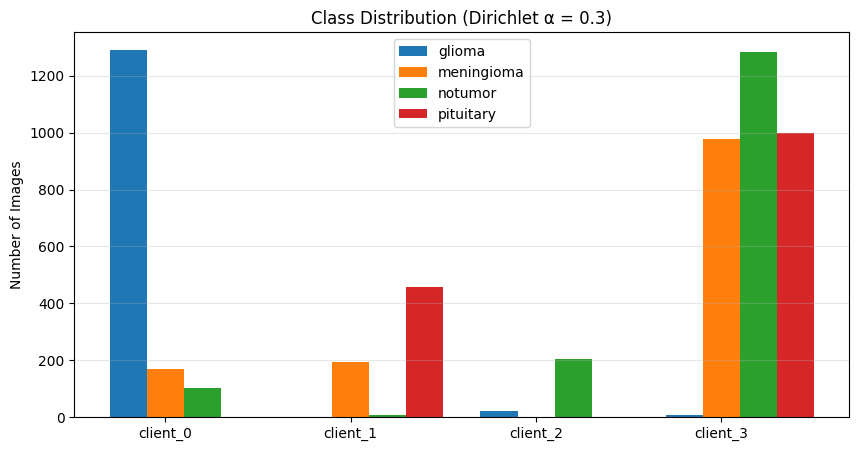

In [4]:
dist_mod = plot_class_distribution(client_subsets, class_names, alpha_value=0.3)


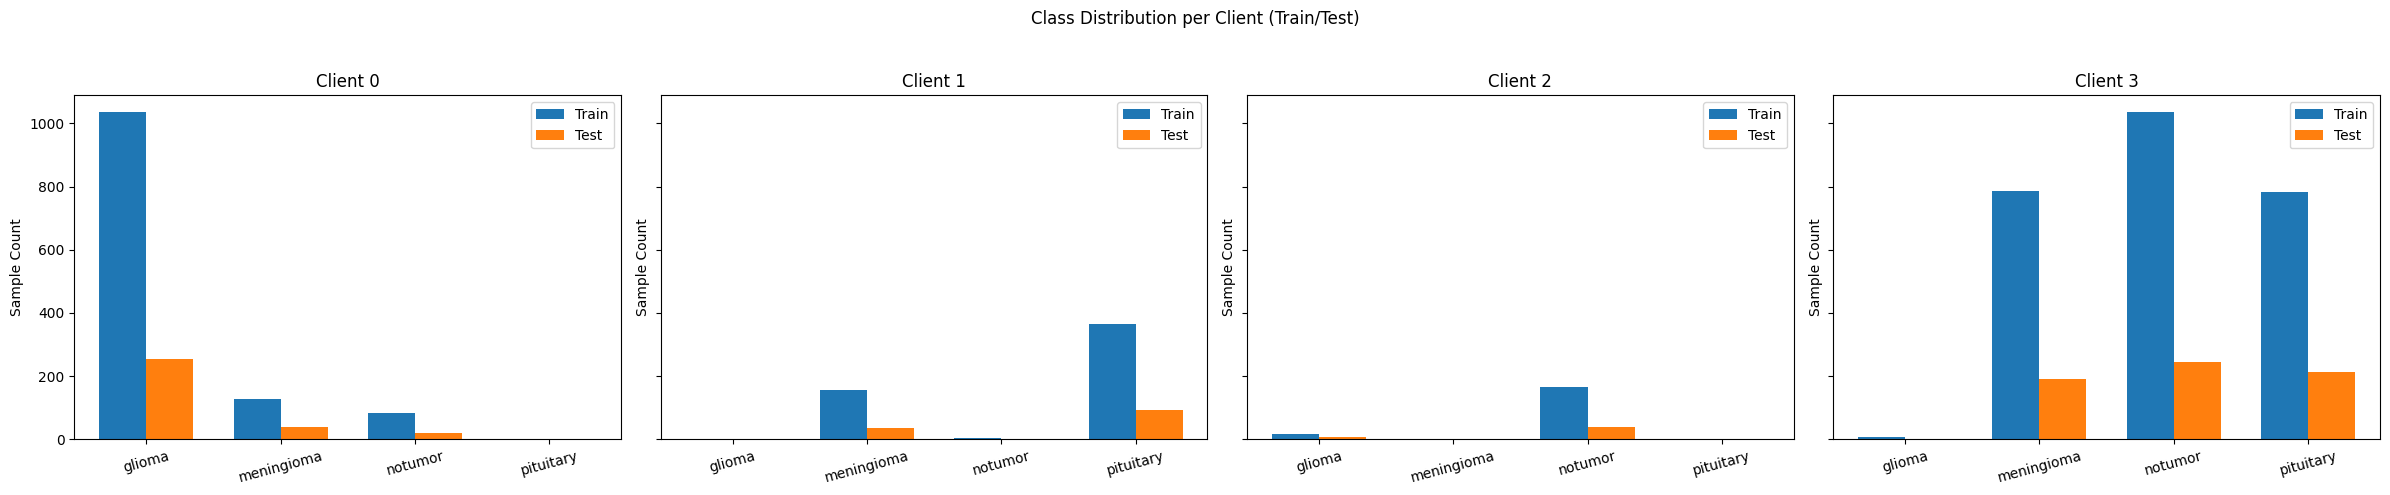

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ---- PREPARE DATA FOR PLOTTING ----
client_train_counts = []
client_test_counts = []

for idx, (client_train, client_test) in enumerate(client_data):
    train_labels = [client_train[i][1] for i in range(len(client_train))]
    test_labels = [client_test[i][1] for i in range(len(client_test))]
    train_counts = [train_labels.count(i) for i in range(len(class_names))]
    test_counts = [test_labels.count(i) for i in range(len(class_names))]
    client_train_counts.append(train_counts)
    client_test_counts.append(test_counts)

client_train_counts = np.array(client_train_counts)
client_test_counts = np.array(client_test_counts)

# ---- GROUPED BAR CHART FOR EACH CLIENT ----
num_classes = len(class_names)
num_clients = len(client_data)
x = np.arange(num_classes)  # the label locations

fig, axs = plt.subplots(1, num_clients, figsize=(6 * num_clients, 5), sharey=True)
# Each subplot is for one client
for idx in range(num_clients):
    width = 0.35
    axs[idx].bar(x - width/2, client_train_counts[idx], width, label='Train', color='tab:blue')
    axs[idx].bar(x + width/2, client_test_counts[idx], width, label='Test', color='tab:orange')
    axs[idx].set_xticks(x)
    axs[idx].set_xticklabels(class_names, rotation=15)
    axs[idx].set_ylabel('Sample Count')
    axs[idx].set_title(f'Client {idx}')
    axs[idx].legend()

plt.suptitle('Class Distribution per Client (Train/Test)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


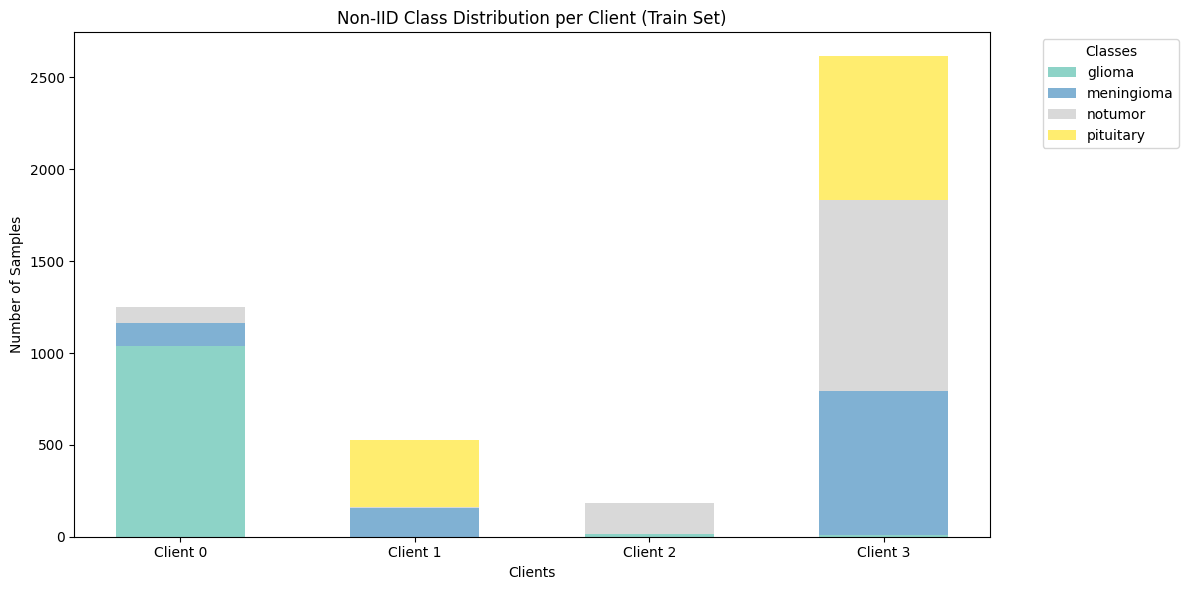

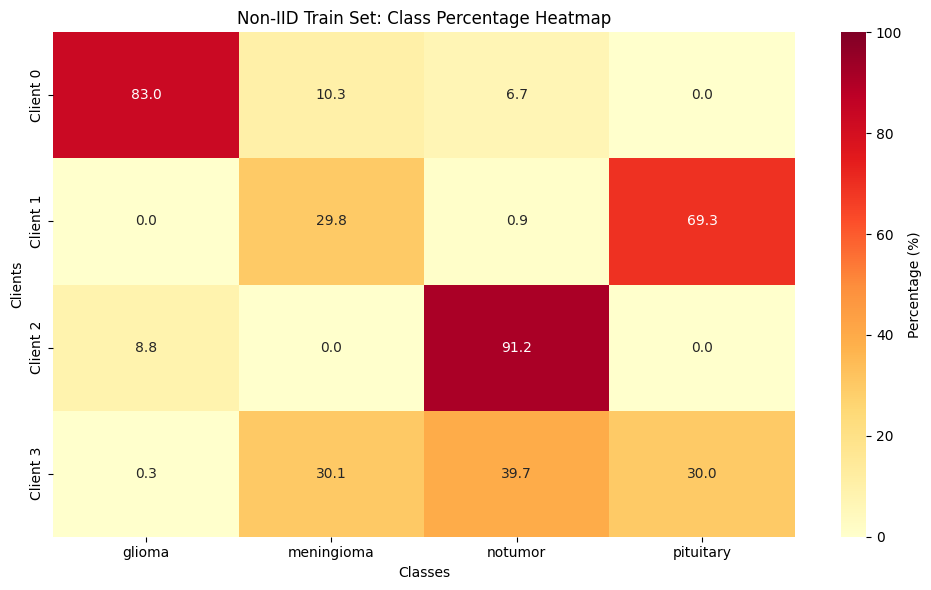

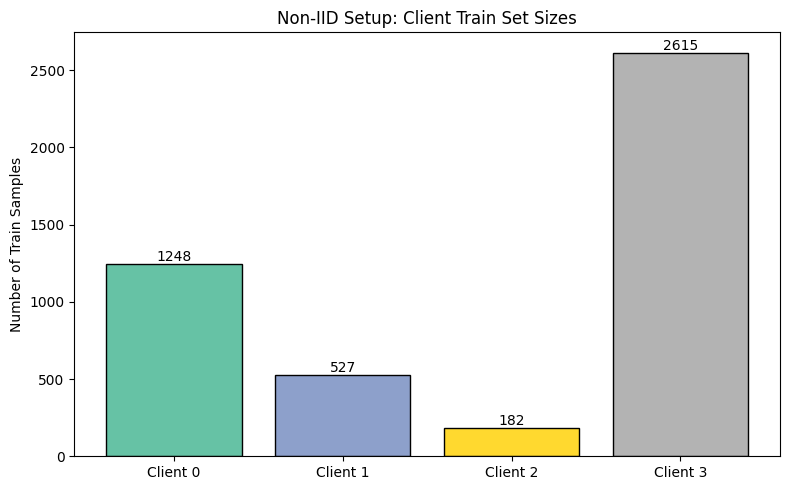

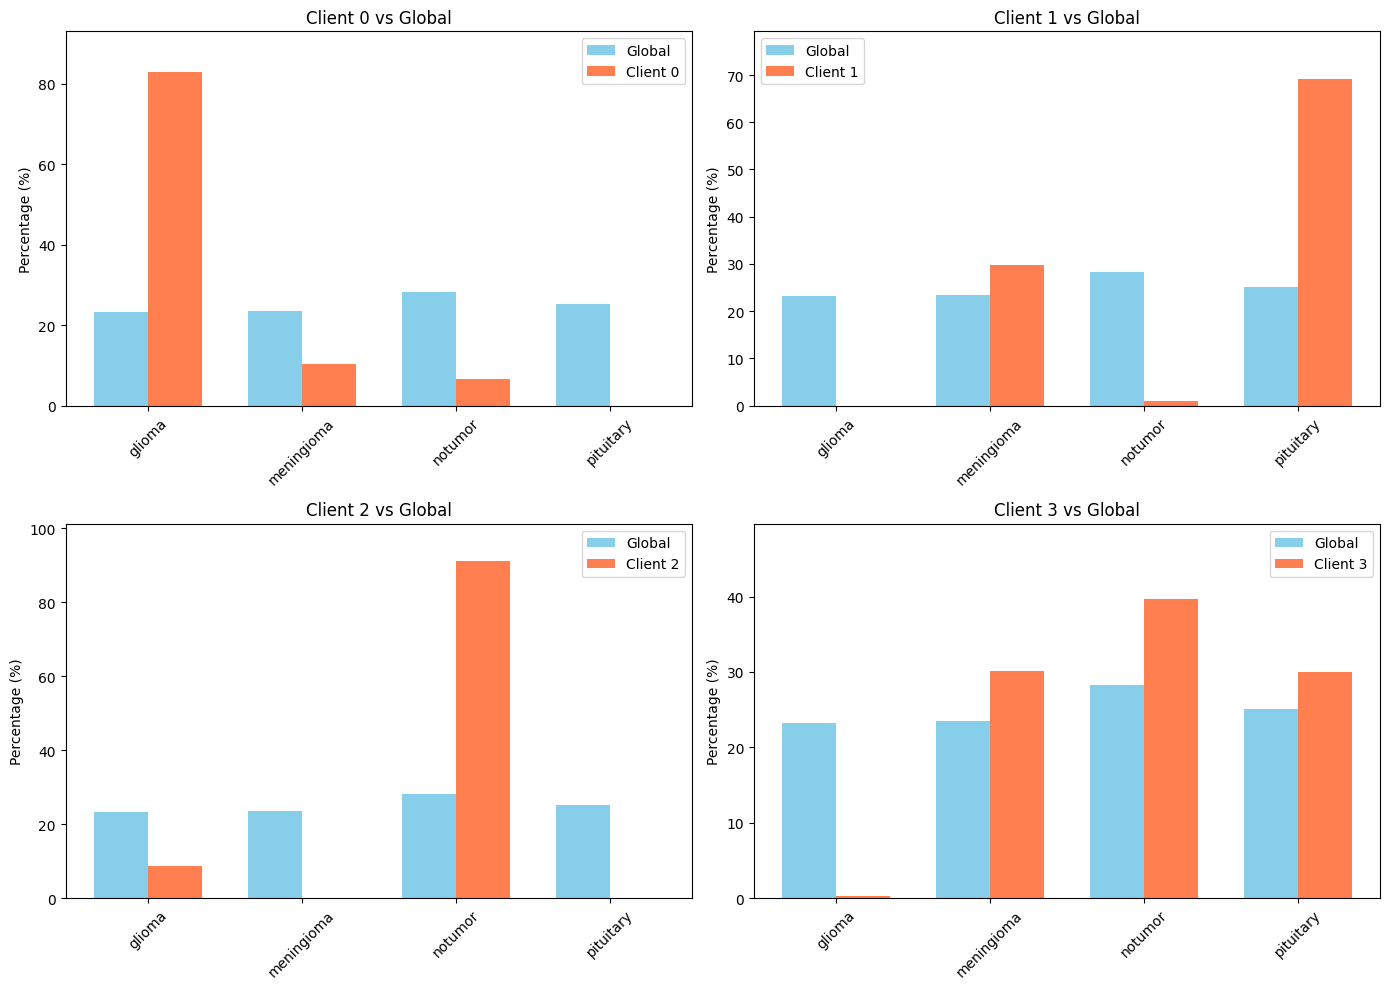


NON-IID DATA DISTRIBUTION SUMMARY (Train)

Client 0: 1248 samples
  glioma: 1036 (83.0%)
  meningioma: 129 (10.3%)
  notumor: 83 (6.7%)
  pituitary: 0 (0.0%)

Client 1: 527 samples
  glioma: 0 (0.0%)
  meningioma: 157 (29.8%)
  notumor: 5 (0.9%)
  pituitary: 365 (69.3%)

Client 2: 182 samples
  glioma: 16 (8.8%)
  meningioma: 0 (0.0%)
  notumor: 166 (91.2%)
  pituitary: 0 (0.0%)

Client 3: 2615 samples
  glioma: 7 (0.3%)
  meningioma: 787 (30.1%)
  notumor: 1037 (39.7%)
  pituitary: 784 (30.0%)

Global Distribution (Train Set):
  glioma: 1059 (23.2%)
  meningioma: 1073 (23.5%)
  notumor: 1291 (28.2%)
  pituitary: 1149 (25.1%)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

# ----- 1. Collect train set class counts for each client -----
client_class_dist = []
for client_train, _ in client_data:  # only train split
    labels = [client_train[i][1] for i in range(len(client_train))]
    counts = [labels.count(i) for i in range(len(class_names))]
    client_class_dist.append(counts)

num_clients = len(client_class_dist)
num_classes = len(class_names)

# ----- 2. Stacked bar chart: class samples per client -----
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(num_clients)
bottom = np.zeros(num_clients)
colors = plt.cm.Set3(np.linspace(0, 1, num_classes))

for class_idx in range(num_classes):
    values = [client_class_dist[cidx][class_idx] for cidx in range(num_clients)]
    ax.bar(x, values, bottom=bottom, width=0.55, color=colors[class_idx], label=class_names[class_idx])
    bottom += np.array(values)
ax.set_xticks(x)
ax.set_xticklabels([f"Client {i}" for i in range(num_clients)])
ax.set_ylabel("Number of Samples")
ax.set_xlabel("Clients")
ax.set_title("Non-IID Class Distribution per Client (Train Set)")
ax.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ----- 3. Heatmap: class percentage per client -----
heatmap_data = []
for counts in client_class_dist:
    total = sum(counts)
    row = [100 * c / total if total > 0 else 0 for c in counts]
    heatmap_data.append(row)
heatmap_data = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Percentage (%)'},
            xticklabels=class_names, yticklabels=[f"Client {i}" for i in range(num_clients)], ax=ax, vmin=0, vmax=100)
ax.set_title("Non-IID Train Set: Class Percentage Heatmap")
ax.set_xlabel("Classes")
ax.set_ylabel("Clients")
plt.tight_layout()
plt.show()

# ----- 4. Bar chart: client train set sizes -----
client_sizes = [sum(counts) for counts in client_class_dist]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f"Client {i}" for i in range(num_clients)], client_sizes, color=plt.cm.Set2(np.linspace(0,1,num_clients)), edgecolor='black')
ax.set_ylabel("Number of Train Samples")
ax.set_title("Non-IID Setup: Client Train Set Sizes")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# ----- 5. Comparison: global distribution vs client -----
global_counts = [0 for _ in range(num_classes)]
for client_train, _ in client_data:
    labels = [client_train[i][1] for i in range(len(client_train))]
    for i in labels:
        global_counts[i] += 1
global_total = sum(global_counts)
global_percentages = [100 * c / global_total for c in global_counts]

fig, axes = plt.subplots(2, (num_clients+1)//2, figsize=(14, 10))
axes = axes.flatten()
for idx in range(num_clients):
    client_total = sum(client_class_dist[idx])
    client_percentages = [100 * n / client_total if client_total > 0 else 0 for n in client_class_dist[idx]]
    x_pos = np.arange(num_classes)
    width = 0.35
    axes[idx].bar(x_pos - width/2, global_percentages, width, label='Global', color='skyblue')
    axes[idx].bar(x_pos + width/2, client_percentages, width, label=f'Client {idx}', color='coral')
    axes[idx].set_title(f"Client {idx} vs Global")
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(class_names, rotation=45)
    axes[idx].set_ylabel("Percentage (%)")
    axes[idx].legend()
    axes[idx].set_ylim([0, max(global_percentages + client_percentages) + 10])
plt.tight_layout()
plt.show()

# ----- 6. Summary statistics -----
print("\n" + "="*50)
print("NON-IID DATA DISTRIBUTION SUMMARY (Train)")
print("="*50)
for idx, counts in enumerate(client_class_dist):
    client_total = sum(counts)
    print(f"\nClient {idx}: {client_total} samples")
    for class_idx, class_name in enumerate(class_names):
        pct = 100 * counts[class_idx] / client_total if client_total > 0 else 0
        print(f"  {class_name}: {counts[class_idx]} ({pct:.1f}%)")

print("\n" + "="*50)
print("Global Distribution (Train Set):")
print("="*50)
for class_idx, class_name in enumerate(class_names):
    pct = 100 * global_counts[class_idx] / global_total if global_total > 0 else 0
    print(f"  {class_name}: {global_counts[class_idx]} ({pct:.1f}%)")
print("="*50)


In [8]:
import numpy as np
from scipy.spatial.distance import jensenshannon

# ----- 1. Prepare class distributions -----

# Get number of classes
num_classes = len(train_dataset.classes)

# Extract class distributions for each client
client_distributions = []
for k in range(NUM_CLIENTS):
    idxs = client_indices[k]
    counts = np.zeros(num_classes)
    for i in idxs:
        class_idx = train_dataset.samples[i][1]  # (filename, class_idx)
        counts[class_idx] += 1
    # Normalize to probabilities
    if counts.sum() > 0:
        prob_vec = counts / counts.sum()
    else:
        prob_vec = counts
    client_distributions.append(prob_vec)

# ----- 2. Compute global class distribution -----
global_counts = np.zeros(num_classes)
for sample in train_dataset.samples:
    class_idx = sample[1]
    global_counts[class_idx] += 1
global_dist = global_counts / global_counts.sum()

print("Global Distribution:", global_dist)
print("Classes:", train_dataset.classes)

# ----- 3. Compute Jensen-Shannon Divergence (JS Divergence) -----
print("\n" + "="*70)
print("JENSEN-SHANNON DIVERGENCE (Client vs Global)")
print("="*70)
print("Range: 0 (identical) to 1 (completely different)\n")

js_divergences = []
for k, client_dist in enumerate(client_distributions):
    js_div = jensenshannon(global_dist, client_dist)
    js_divergences.append(js_div)
    print(f"Client {k}: JS Divergence = {js_div:.4f}")

avg_js = np.mean(js_divergences)
print(f"\nAverage JS Divergence: {avg_js:.4f}")


Global Distribution: [0.23126751 0.23441877 0.27923669 0.25507703]
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

JENSEN-SHANNON DIVERGENCE (Client vs Global)
Range: 0 (identical) to 1 (completely different)

Client 0: JS Divergence = 0.4744
Client 1: JS Divergence = 0.4636
Client 2: JS Divergence = 0.5180
Client 3: JS Divergence = 0.2855

Average JS Divergence: 0.4354


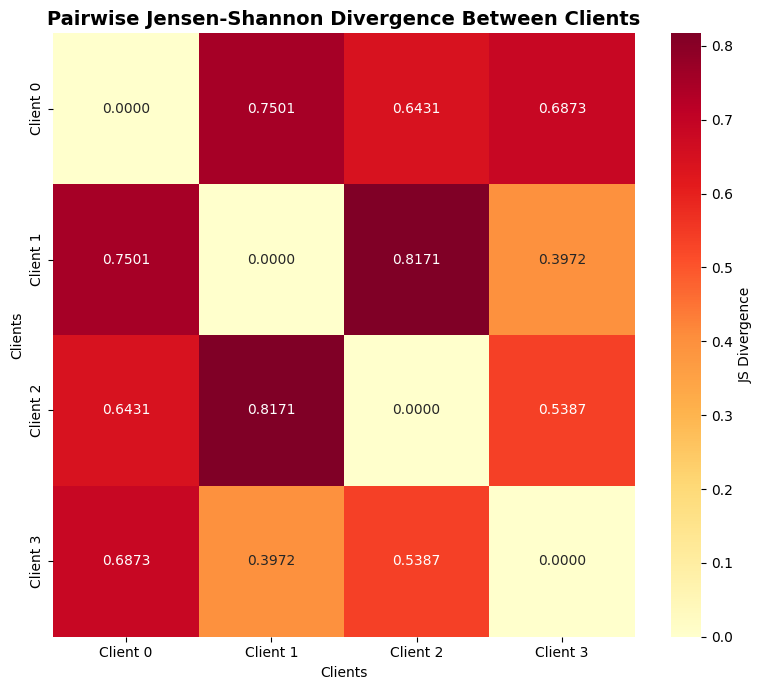

In [9]:
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import seaborn as sns

# ----- 1. Prepare client class probability distributions -----
num_classes = len(train_dataset.classes)
client_distributions = []
for k in range(NUM_CLIENTS):
    idxs = client_indices[k]
    counts = np.zeros(num_classes)
    for i in idxs:
        class_idx = train_dataset.samples[i][1]
        counts[class_idx] += 1
    prob_vec = counts / counts.sum() if counts.sum() > 0 else counts
    client_distributions.append(prob_vec)

# ----- 2. Compute pairwise JS divergence matrix -----
pairwise_js = np.zeros((NUM_CLIENTS, NUM_CLIENTS))
for i in range(NUM_CLIENTS):
    for j in range(NUM_CLIENTS):
        pairwise_js[i, j] = jensenshannon(client_distributions[i], client_distributions[j])

# ----- 3. Plot pairwise JS divergence heatmap -----
plt.figure(figsize=(8, 7))
sns.heatmap(pairwise_js, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'Client {i}' for i in range(NUM_CLIENTS)],
            yticklabels=[f'Client {i}' for i in range(NUM_CLIENTS)],
            cbar_kws={'label': 'JS Divergence'})
plt.title('Pairwise Jensen-Shannon Divergence Between Clients', fontsize=14, fontweight='bold')
plt.xlabel('Clients')
plt.ylabel('Clients')
plt.tight_layout()
plt.show()


In [10]:
# ============================================================
#     FEDAVG (MODERATE NON-IID α = 0.3) — PRETRAINED RESNET18
#     Iteration-based, Adam, Early Stopping, LR = 1e-4
# ============================================================

import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader

# ============================================================
#                    DEVICE SETUP
# ============================================================
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🚀 Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🚀 Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print("🖥 Using CPU")


# ============================================================
#   CONFIG (MODERATE NON-IID α=0.3 — FEDAVG)
# ============================================================
SEED_MOD_A3 = 77
NUM_ROUNDS_MOD_A3 = 300
LOCAL_ITERS_MOD_A3 = 10
LR_MOD_A3 = 1e-4
BATCH_SIZE_MOD_A3 = 32
PATIENCE_MOD_A3 = 25

NUM_CLIENTS_MOD_A3 = len(client_data)
NUM_CLASSES_MOD_A3 = len(train_dataset.classes)

# Reproducibility
random.seed(SEED_MOD_A3)
np.random.seed(SEED_MOD_A3)
torch.manual_seed(SEED_MOD_A3)
torch.cuda.manual_seed_all(SEED_MOD_A3)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

criterion_mod_a3 = nn.CrossEntropyLoss()


# ============================================================
#               PRETRAINED RESNET18 (FROZEN EARLY LAYERS)
# ============================================================
def create_pretrained_resnet18_mod_a3(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze early layers
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters(): p.requires_grad = False
    for p in model.layer1.parameters(): p.requires_grad = False
    for p in model.layer2.parameters(): p.requires_grad = False

    # Train only deeper layers
    for p in model.layer3.parameters(): p.requires_grad = True
    for p in model.layer4.parameters(): p.requires_grad = True

    # Replace FC head
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ============================================================
#         ITERATION-BASED LOCAL TRAINING (NO EPOCHS)
# ============================================================
def train_iterations_mod_a3(model, loader, device, optimizer, num_steps):

    model.train()
    iterator = iter(loader)

    tot_loss = 0
    tot_corr = 0
    tot = 0

    for step in range(num_steps):

        try:
            x, y = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            x, y = next(iterator)

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion_mod_a3(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        tot_loss += loss.item() * bs
        tot_corr += (logits.argmax(1) == y).sum().item()
        tot += bs

    return {"loss": tot_loss / tot, "acc": tot_corr / tot}


# ============================================================
#                      EVALUATION FUNCTION
# ============================================================
@torch.no_grad()
def evaluate_mod_a3(model, loader, device):
    model.eval()
    tot_loss = tot_corr = tot = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion_mod_a3(logits, y)

        bs = x.size(0)
        tot_loss += loss.item() * bs
        tot_corr += (logits.argmax(1) == y).sum().item()
        tot += bs

    return {"loss": tot_loss / tot, "acc": tot_corr / tot}


# ============================================================
#                 CLIENT DATA LOADERS (MODERATE)
# ============================================================
client_train_loaders_mod_a3 = []
client_test_loaders_mod_a3 = []

for tset, vset in client_data:
    client_train_loaders_mod_a3.append(
        DataLoader(tset, batch_size=BATCH_SIZE_MOD_A3, shuffle=True)
    )
    client_test_loaders_mod_a3.append(
        DataLoader(vset, batch_size=BATCH_SIZE_MOD_A3, shuffle=False)
    )


# ============================================================
#                 GLOBAL HOLDOUT LOADER
# ============================================================
holdout_loader_mod_a3 = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_MOD_A3,
    shuffle=False
)


# ============================================================
#                GLOBAL MODEL INITIALIZATION
# ============================================================
global_model_mod_a3 = create_pretrained_resnet18_mod_a3(NUM_CLASSES_MOD_A3).to(DEVICE)

best_acc_mod_a3 = -1.0
best_state_mod_a3 = None
no_improve_mod_a3 = 0

metrics_history_fedavg_moderate_pretrained_alpha3 = {
    "round": [],
    "holdout": [],
    "clients": {k: [] for k in range(NUM_CLIENTS_MOD_A3)},
}


# ============================================================
#                  FEDAVG TRAINING LOOP
# ============================================================
for rnd in range(NUM_ROUNDS_MOD_A3):

    print(f"\n🔁 [MODERATE α=0.3] FedAvg Round {rnd+1}/{NUM_ROUNDS_MOD_A3}")

    local_states = []

    # ----- CLIENT-SIDE TRAINING -----
    for k in range(NUM_CLIENTS_MOD_A3):

        local_model = copy.deepcopy(global_model_mod_a3).to(DEVICE)

        optimizer = optim.Adam(
            (p for p in local_model.parameters() if p.requires_grad),
            lr=LR_MOD_A3
        )

        train_metrics = train_iterations_mod_a3(
            local_model,
            client_train_loaders_mod_a3[k],
            DEVICE,
            optimizer,
            num_steps=LOCAL_ITERS_MOD_A3
        )

        local_states.append({
            name: param.cpu() for name, param in local_model.state_dict().items()
        })

        client_metric = evaluate_mod_a3(local_model, client_test_loaders_mod_a3[k], DEVICE)
        metrics_history_fedavg_moderate_pretrained_alpha3["clients"][k].append(client_metric)

        print(f"  Client {k} | Train Acc: {train_metrics['acc']:.4f} | Local Test Acc: {client_metric['acc']:.4f}")


    # ----- FEDAVG AGGREGATION -----
    new_state = {}
    for key in global_model_mod_a3.state_dict().keys():
        stacked = torch.stack([s[key] for s in local_states], dim=0)
        new_state[key] = stacked.mean(dim=0) if stacked.dtype.is_floating_point else stacked[0]

    global_model_mod_a3.load_state_dict(new_state)

    # ----- GLOBAL HOLDOUT EVAL -----
    holdout_metric = evaluate_mod_a3(global_model_mod_a3, holdout_loader_mod_a3, DEVICE)

    metrics_history_fedavg_moderate_pretrained_alpha3["round"].append(rnd + 1)
    metrics_history_fedavg_moderate_pretrained_alpha3["holdout"].append(holdout_metric)

    print(f"🌍 Global Holdout | Acc: {holdout_metric['acc']:.4f}, Loss: {holdout_metric['loss']:.4f}")


    # ----- EARLY STOPPING -----
    if holdout_metric["acc"] > best_acc_mod_a3:
        best_acc_mod_a3 = holdout_metric["acc"]
        best_state_mod_a3 = copy.deepcopy(global_model_mod_a3.state_dict())
        no_improve_mod_a3 = 0
        print(f"💾 New BEST Moderate α=0.3 Model Saved! Acc = {best_acc_mod_a3:.4f}")
    else:
        no_improve_mod_a3 += 1
        print(f"⏳ No improvement {no_improve_mod_a3}/{PATIENCE_MOD_A3}")

    if no_improve_mod_a3 >= PATIENCE_MOD_A3:
        print("\n🛑 Early stopping triggered for MODERATE α=0.3 FedAvg!")
        break


# ============================================================
#                     SAVE RESULTS
# ============================================================
torch.save(best_state_mod_a3, "best_fedavg_moderate_pretrained_alpha3.pth")

np.save(
    "metrics_history_fedavg_moderate_pretrained_alpha3.npy",
    metrics_history_fedavg_moderate_pretrained_alpha3,
    allow_pickle=True
)

print("\n✅ Saved:")
print("   • best_fedavg_moderate_pretrained_alpha3.pth")
print("   • metrics_history_fedavg_moderate_pretrained_alpha3.npy")


🚀 Using Apple Silicon GPU (MPS)

🔁 [MODERATE α=0.3] FedAvg Round 1/300
  Client 0 | Train Acc: 0.5844 | Local Test Acc: 0.8103
  Client 1 | Train Acc: 0.6594 | Local Test Acc: 0.6260
  Client 2 | Train Acc: 0.8516 | Local Test Acc: 0.9556
  Client 3 | Train Acc: 0.7531 | Local Test Acc: 0.7397
🌍 Global Holdout | Acc: 0.5919, Loss: 1.0403
💾 New BEST Moderate α=0.3 Model Saved! Acc = 0.5919

🔁 [MODERATE α=0.3] FedAvg Round 2/300
  Client 0 | Train Acc: 0.6312 | Local Test Acc: 0.8328
  Client 1 | Train Acc: 0.8094 | Local Test Acc: 0.4046
  Client 2 | Train Acc: 0.9323 | Local Test Acc: 0.9333
  Client 3 | Train Acc: 0.8969 | Local Test Acc: 0.7734
🌍 Global Holdout | Acc: 0.6171, Loss: 0.9037
💾 New BEST Moderate α=0.3 Model Saved! Acc = 0.6171

🔁 [MODERATE α=0.3] FedAvg Round 3/300
  Client 0 | Train Acc: 0.6719 | Local Test Acc: 0.7331
  Client 1 | Train Acc: 0.8719 | Local Test Acc: 0.4046
  Client 2 | Train Acc: 0.9290 | Local Test Acc: 0.9111
  Client 3 | Train Acc: 0.9000 | Local Te

Using: mps
Loaded best FedAvg α=0.3 model ✔

===== FINAL EVALUATION — FedAvg Moderate Non-IID (α = 0.3) =====
loss: 0.1355
acc: 0.9634
precision: 0.9632
recall: 0.9602
f1: 0.9607


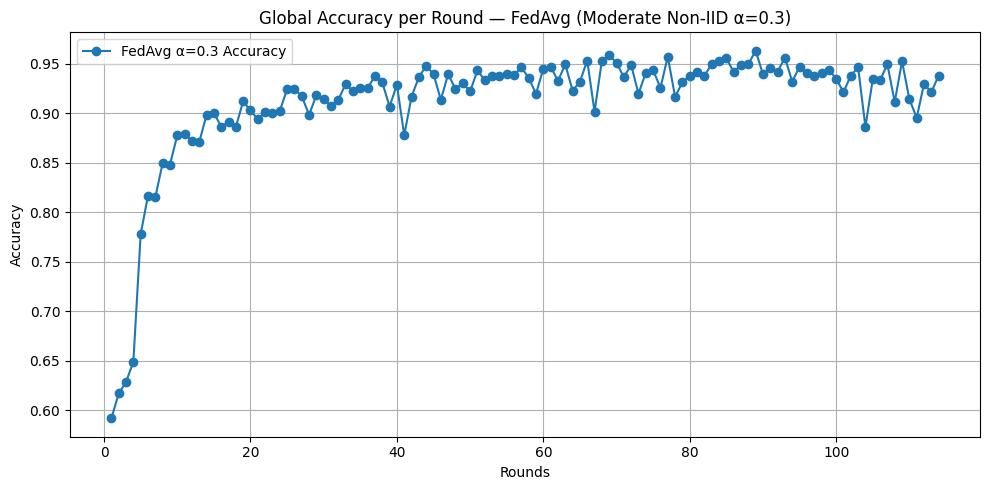

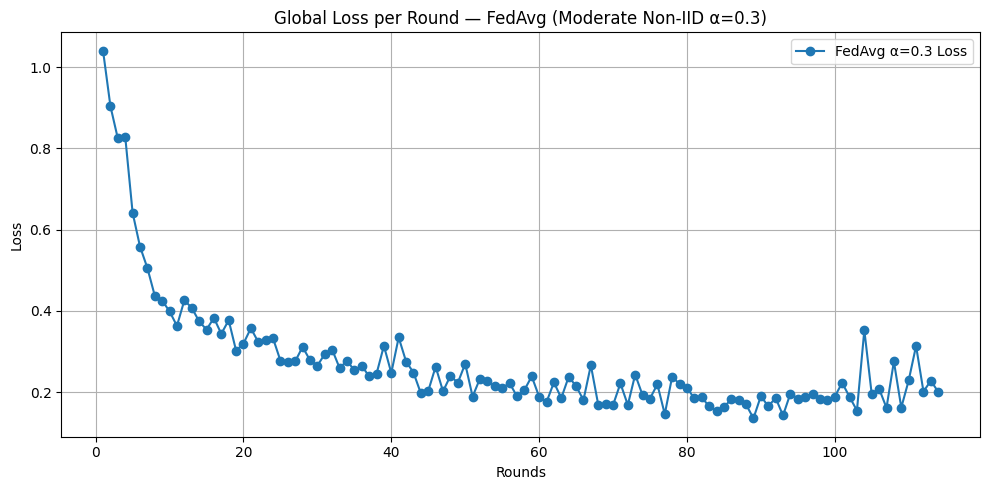

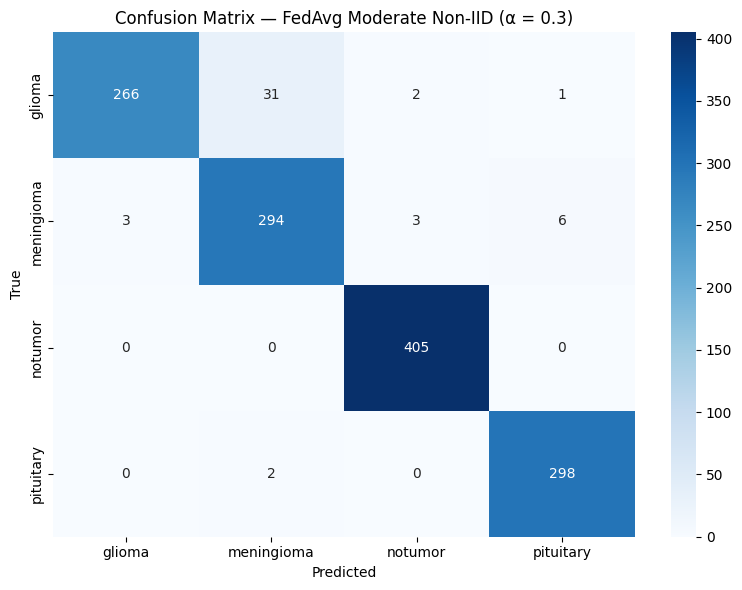


Saved confusion matrix → fedavg_moderate_alpha3_confusion_matrix.npy


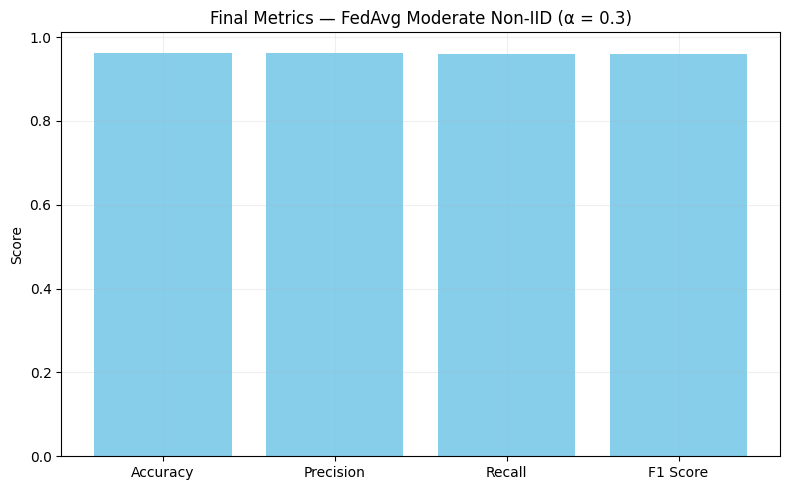

In [11]:
# ============================================================
#     EVALUATION — FedAvg (Moderate Non-IID α = 0.3)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader


# ============================================================
# DEVICE SETUP
# ============================================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print("Using:", DEVICE)


# ============================================================
# REBUILD RESNET18 ARCHITECTURE (same freezing as training)
# ============================================================
def create_resnet18_mod_a3_eval(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # match freezing (though eval ignores requires_grad)
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters(): p.requires_grad = False
    for p in model.layer1.parameters(): p.requires_grad = False
    for p in model.layer2.parameters(): p.requires_grad = False
    for p in model.layer3.parameters(): p.requires_grad = True
    for p in model.layer4.parameters(): p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


NUM_CLASSES = len(train_dataset.classes)


# ============================================================
# LOAD TRAINED MODEL
# ============================================================
model_mod_a3 = create_resnet18_mod_a3_eval(NUM_CLASSES).to(DEVICE)
model_mod_a3.load_state_dict(torch.load("best_fedavg_moderate_pretrained_alpha3.pth",
                                        map_location=DEVICE))
model_mod_a3.eval()

print("Loaded best FedAvg α=0.3 model ✔")


# ============================================================
# GLOBAL TEST LOADER
# ============================================================
holdout_loader_mod_a3 = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=0
)


# ============================================================
# EVALUATION FUNCTION
# ============================================================
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate_full(model, loader):
    total_loss = 0
    preds_all = []
    labels_all = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds_all.append(logits.argmax(1).cpu())
        labels_all.append(y.cpu())

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    return {
        "loss": total_loss / len(labels_all),
        "acc": (preds_all == labels_all).mean(),
        "precision": precision_score(labels_all, preds_all, average="macro", zero_division=0),
        "recall": recall_score(labels_all, preds_all, average="macro", zero_division=0),
        "f1": f1_score(labels_all, preds_all, average="macro", zero_division=0),
        "preds": preds_all,
        "labels": labels_all
    }


# ============================================================
# PERFORM EVALUATION
# ============================================================
results_mod_a3 = evaluate_full(model_mod_a3, holdout_loader_mod_a3)

print("\n===== FINAL EVALUATION — FedAvg Moderate Non-IID (α = 0.3) =====")
for k, v in results_mod_a3.items():
    if k not in ("preds", "labels"):
        print(f"{k}: {v:.4f}")


# ============================================================
# LOAD METRICS HISTORY
# ============================================================
hist_mod_a3 = np.load("metrics_history_fedavg_moderate_pretrained_alpha3.npy",
                      allow_pickle=True).item()

rounds = hist_mod_a3["round"]
accs = [m["acc"] for m in hist_mod_a3["holdout"]]
losses = [m["loss"] for m in hist_mod_a3["holdout"]]


# ============================================================
# ACCURACY CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds, accs, marker="o", label="FedAvg α=0.3 Accuracy")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Global Accuracy per Round — FedAvg (Moderate Non-IID α=0.3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# LOSS CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds, losses, marker="o", label="FedAvg α=0.3 Loss")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.title("Global Loss per Round — FedAvg (Moderate Non-IID α=0.3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(results_mod_a3["labels"], results_mod_a3["preds"])
class_names = train_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — FedAvg Moderate Non-IID (α = 0.3)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Save confusion matrix
np.save("fedavg_moderate_alpha3_confusion_matrix.npy", cm)
print("\nSaved confusion matrix → fedavg_moderate_alpha3_confusion_matrix.npy")


# ============================================================
# BAR PLOT — FINAL METRICS
# ============================================================
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [
    results_mod_a3["acc"],
    results_mod_a3["precision"],
    results_mod_a3["recall"],
    results_mod_a3["f1"],
]

plt.figure(figsize=(8,5))
plt.bar(labels, values, color="skyblue")
plt.ylabel("Score")
plt.title("Final Metrics — FedAvg Moderate Non-IID (α = 0.3)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
#     FEDPROX (MODERATE NON-IID α = 0.3) — PRETRAINED RESNET18
#     Iteration-based, Adam, Early Stopping, LR = 1e-4, μ = 0.1
# ============================================================

import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader

# ============================================================
#                    DEVICE SETUP
# ============================================================
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🚀 Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🚀 Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print("🖥 Using CPU")


# ============================================================
#          CONFIG (MODERATE NON-IID α=0.3 — FEDPROX)
# ============================================================
SEED_MOD_FP_A3 = 77
NUM_ROUNDS_MOD_FP_A3 = 300
LOCAL_ITERS_MOD_FP_A3 = 10
LR_MOD_FP_A3 = 1e-4
BATCH_SIZE_MOD_FP_A3 = 32
FEDPROX_MU_MOD_A3 = 0.1
PATIENCE_MOD_FP_A3 = 25

NUM_CLIENTS_MOD_FP_A3 = len(client_data)
NUM_CLASSES_MOD_FP_A3 = len(train_dataset.classes)

# Reproducibility
random.seed(SEED_MOD_FP_A3)
np.random.seed(SEED_MOD_FP_A3)
torch.manual_seed(SEED_MOD_FP_A3)
torch.cuda.manual_seed_all(SEED_MOD_FP_A3)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

criterion_mod_fp_a3 = nn.CrossEntropyLoss()


# ============================================================
#     PRETRAINED RESNET18 (FROZEN EARLY LAYERS)
# ============================================================
def create_pretrained_resnet18_mod_fp_a3(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze early layers
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters(): p.requires_grad = False
    for p in model.layer1.parameters(): p.requires_grad = False
    for p in model.layer2.parameters(): p.requires_grad = False

    # Train deeper layers
    for p in model.layer3.parameters(): p.requires_grad = True
    for p in model.layer4.parameters(): p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ============================================================
#     FEDPROX ITERATION-BASED LOCAL TRAINING
# ============================================================
def train_fedprox_iterations_mod_a3(
    model, loader, device, optimizer, global_params, mu, num_steps
):
    model.train()
    iterator = iter(loader)

    tot_loss = tot_corr = tot = 0

    for step in range(num_steps):

        try:
            x, y = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            x, y = next(iterator)

        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        ce_loss = criterion_mod_fp_a3(logits, y)

        # FedProx proximal term
        prox_term = 0.0
        for name, param in model.named_parameters():
            if param.requires_grad:
                prox_term += ((param - global_params[name]) ** 2).sum()

        loss = ce_loss + (mu / 2) * prox_term
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        tot_loss += loss.item() * bs
        tot_corr += (logits.argmax(1) == y).sum().item()
        tot += bs

    return {"loss": tot_loss / tot, "acc": tot_corr / tot}


# ============================================================
#                      EVALUATION
# ============================================================
@torch.no_grad()
def evaluate_mod_fp_a3(model, loader, device):
    model.eval()
    tot_loss = tot_corr = tot = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion_mod_fp_a3(logits, y)

        bs = x.size(0)
        tot_loss += loss.item() * bs
        tot_corr += (logits.argmax(1) == y).sum().item()
        tot += bs

    return {"loss": tot_loss / tot, "acc": tot_corr / tot}


# ============================================================
#           CLIENT DATA LOADERS
# ============================================================
client_train_loaders_mod_fp_a3 = []
client_test_loaders_mod_fp_a3 = []

for tset, vset in client_data:
    client_train_loaders_mod_fp_a3.append(
        DataLoader(tset, batch_size=BATCH_SIZE_MOD_FP_A3, shuffle=True)
    )
    client_test_loaders_mod_fp_a3.append(
        DataLoader(vset, batch_size=BATCH_SIZE_MOD_FP_A3, shuffle=False)
    )


# ============================================================
#           GLOBAL HOLDOUT LOADER
# ============================================================
holdout_loader_mod_fp_a3 = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_MOD_FP_A3,
    shuffle=False
)


# ============================================================
#        GLOBAL MODEL INITIALIZATION
# ============================================================
global_model_mod_fp_a3 = create_pretrained_resnet18_mod_fp_a3(NUM_CLASSES_MOD_FP_A3).to(DEVICE)

best_acc_mod_fp_a3 = -1.0
best_state_mod_fp_a3 = None
no_improve_mod_fp_a3 = 0

metrics_history_fedprox_moderate_pretrained_alpha3 = {
    "round": [],
    "holdout": [],
    "clients": {k: [] for k in range(NUM_CLIENTS_MOD_FP_A3)},
}


# ============================================================
#               FEDPROX TRAINING LOOP
# ============================================================
for rnd in range(NUM_ROUNDS_MOD_FP_A3):

    print(f"\n🔁 [MODERATE α=0.3] FedProx Round {rnd+1}/{NUM_ROUNDS_MOD_FP_A3}")

    local_states = []

    # Copy global params for proximal term
    global_params = {
        name: p.detach().clone().to(DEVICE)
        for name, p in global_model_mod_fp_a3.named_parameters()
    }

    # ----- CLIENT TRAINING -----
    for k in range(NUM_CLIENTS_MOD_FP_A3):

        local_model = copy.deepcopy(global_model_mod_fp_a3).to(DEVICE)
        optimizer = optim.Adam(
            (p for p in local_model.parameters() if p.requires_grad),
            lr=LR_MOD_FP_A3
        )

        train_metrics = train_fedprox_iterations_mod_a3(
            local_model,
            client_train_loaders_mod_fp_a3[k],
            DEVICE,
            optimizer,
            global_params,
            mu=FEDPROX_MU_MOD_A3,
            num_steps=LOCAL_ITERS_MOD_FP_A3
        )

        local_states.append({
            name: param.cpu() for name, param in local_model.state_dict().items()
        })

        client_metric = evaluate_mod_fp_a3(local_model, client_test_loaders_mod_fp_a3[k], DEVICE)
        metrics_history_fedprox_moderate_pretrained_alpha3["clients"][k].append(client_metric)

        print(f"  Client {k} | Train Acc: {train_metrics['acc']:.4f} | Local Test Acc: {client_metric['acc']:.4f}")


    # ----- FEDAVG AGGREGATION (FedProx uses FedAvg aggregator) -----
    new_state = {}
    for key in global_model_mod_fp_a3.state_dict().keys():
        stacked = torch.stack([s[key] for s in local_states], dim=0)
        new_state[key] = stacked.mean(dim=0) if stacked.dtype.is_floating_point else stacked[0]

    global_model_mod_fp_a3.load_state_dict(new_state)

    # ----- GLOBAL HOLDOUT EVAL -----
    holdout_metric = evaluate_mod_fp_a3(global_model_mod_fp_a3, holdout_loader_mod_fp_a3, DEVICE)

    metrics_history_fedprox_moderate_pretrained_alpha3["round"].append(rnd + 1)
    metrics_history_fedprox_moderate_pretrained_alpha3["holdout"].append(holdout_metric)

    print(f"🌍 Global Holdout | Acc: {holdout_metric['acc']:.4f} | Loss: {holdout_metric['loss']:.4f}")


    # ----- EARLY STOPPING -----
    if holdout_metric["acc"] > best_acc_mod_fp_a3:
        best_acc_mod_fp_a3 = holdout_metric["acc"]
        best_state_mod_fp_a3 = copy.deepcopy(global_model_mod_fp_a3.state_dict())
        no_improve_mod_fp_a3 = 0
        print(f"💾 NEW BEST FedProx α=0.3 Model Saved! Acc = {best_acc_mod_fp_a3:.4f}")

    else:
        no_improve_mod_fp_a3 += 1
        print(f"⏳ No improvement {no_improve_mod_fp_a3}/{PATIENCE_MOD_FP_A3}")

    if no_improve_mod_fp_a3 >= PATIENCE_MOD_FP_A3:
        print("\n🛑 Early stopping triggered for FedProx α=0.3!")
        break


# ============================================================
#                     SAVE RESULTS
# ============================================================
torch.save(best_state_mod_fp_a3, "best_fedprox_moderate_pretrained_alpha3.pth")

np.save(
    "metrics_history_fedprox_moderate_pretrained_alpha3.npy",
    metrics_history_fedprox_moderate_pretrained_alpha3,
    allow_pickle=True
)

print("\n✅ Saved:")
print("   • best_fedprox_moderate_pretrained_alpha3.pth")
print("   • metrics_history_fedprox_moderate_pretrained_alpha3.npy")


🚀 Using Apple Silicon GPU (MPS)

🔁 [MODERATE α=0.3] FedProx Round 1/300
  Client 0 | Train Acc: 0.5781 | Local Test Acc: 0.8103
  Client 1 | Train Acc: 0.6594 | Local Test Acc: 0.6260
  Client 2 | Train Acc: 0.8516 | Local Test Acc: 0.9556
  Client 3 | Train Acc: 0.7531 | Local Test Acc: 0.7381
🌍 Global Holdout | Acc: 0.5843 | Loss: 1.0467
💾 NEW BEST FedProx α=0.3 Model Saved! Acc = 0.5843

🔁 [MODERATE α=0.3] FedProx Round 2/300
  Client 0 | Train Acc: 0.6250 | Local Test Acc: 0.8360
  Client 1 | Train Acc: 0.8094 | Local Test Acc: 0.4046
  Client 2 | Train Acc: 0.9323 | Local Test Acc: 0.9333
  Client 3 | Train Acc: 0.8938 | Local Test Acc: 0.7688
🌍 Global Holdout | Acc: 0.6148 | Loss: 0.9085
💾 NEW BEST FedProx α=0.3 Model Saved! Acc = 0.6148

🔁 [MODERATE α=0.3] FedProx Round 3/300
  Client 0 | Train Acc: 0.6656 | Local Test Acc: 0.7235
  Client 1 | Train Acc: 0.8719 | Local Test Acc: 0.3969
  Client 2 | Train Acc: 0.9290 | Local Test Acc: 0.9333
  Client 3 | Train Acc: 0.9031 | Local

Using: mps
Loaded FedProx α = 0.3 model ✔

===== FINAL FEDPROX α=0.3 RESULTS =====
loss: 0.1160
acc: 0.9687
precision: 0.9675
recall: 0.9660
f1: 0.9666


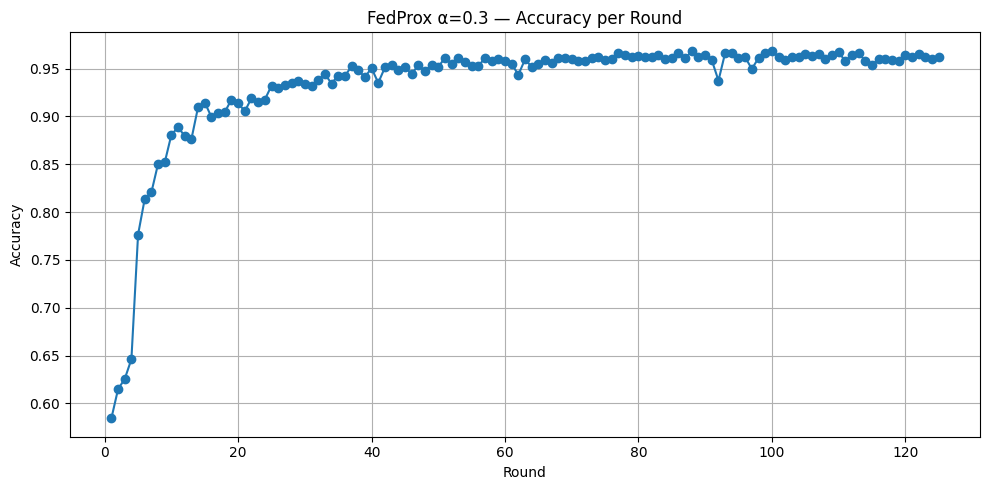

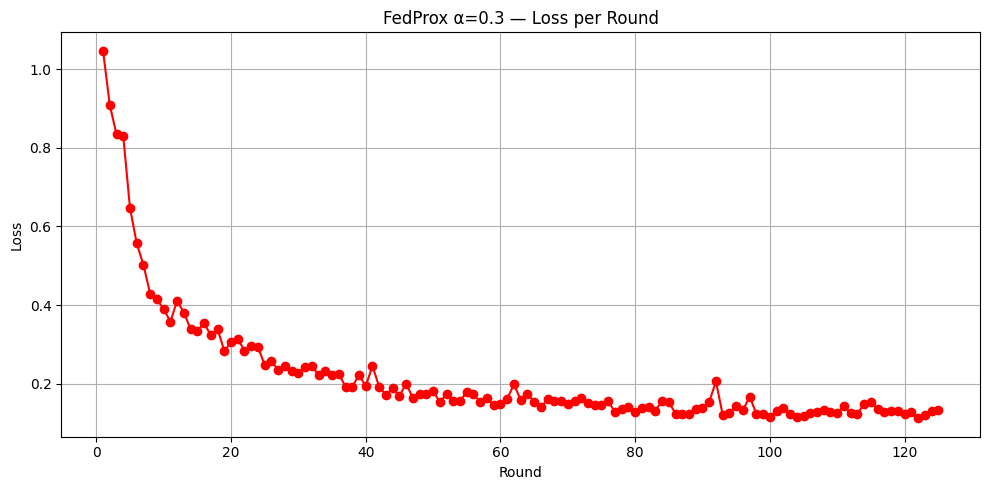

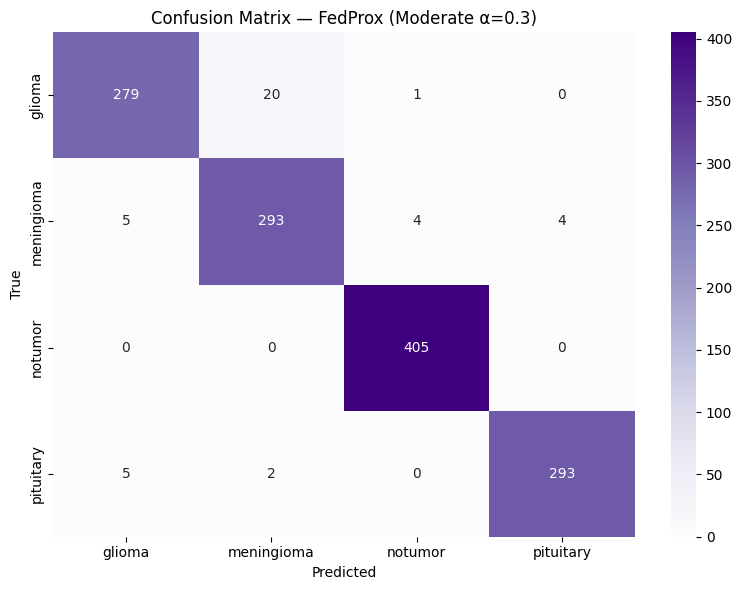

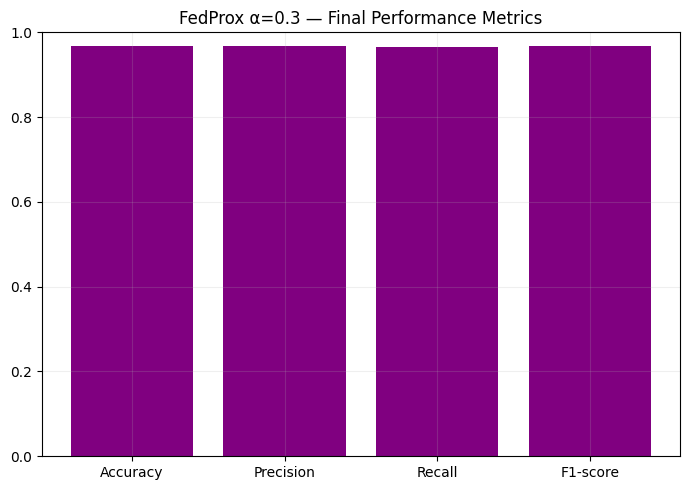

In [13]:
# ============================================================
#     EVALUATION — FEDPROX (MODERATE NON-IID α = 0.3)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models


# ============================================================
# DEVICE
# ============================================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print("Using:", DEVICE)


# ============================================================
# MODEL REBUILDER
# (must match training architecture exactly)
# ============================================================
def create_resnet18_mod_fp_a3(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Frozen layers (same as training)
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters(): p.requires_grad = False
    for p in model.layer1.parameters(): p.requires_grad = False
    for p in model.layer2.parameters(): p.requires_grad = False

    # Trainable deeper layers
    for p in model.layer3.parameters(): p.requires_grad = True
    for p in model.layer4.parameters(): p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


NUM_CLASSES = len(train_dataset.classes)


# ============================================================
# LOAD BEST FEDPROX α=0.3 MODEL
# ============================================================
fedprox_model = create_resnet18_mod_fp_a3(NUM_CLASSES).to(DEVICE)
fedprox_model.load_state_dict(
    torch.load("best_fedprox_moderate_pretrained_alpha3.pth", map_location=DEVICE)
)
fedprox_model.eval()

print("Loaded FedProx α = 0.3 model ✔")


# ============================================================
# GLOBAL TEST LOADER
# ============================================================
holdout_loader_mod_fp_a3 = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# ============================================================
# GENERIC EVALUATION FUNCTION
# ============================================================
crit = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate_full(model, loader):
    preds_all, labels_all = [], []
    total_loss = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = crit(logits, y)

        preds_all.append(logits.argmax(1).cpu())
        labels_all.append(y.cpu())

        total_loss += loss.item() * x.size(0)

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    return {
        "loss": total_loss / len(labels_all),
        "acc": (preds_all == labels_all).mean(),
        "precision": precision_score(labels_all, preds_all, average="macro", zero_division=0),
        "recall": recall_score(labels_all, preds_all, average="macro", zero_division=0),
        "f1": f1_score(labels_all, preds_all, average="macro", zero_division=0),
        "preds": preds_all,
        "labels": labels_all
    }


# ============================================================
# FINAL EVALUATION
# ============================================================
res = evaluate_full(fedprox_model, holdout_loader_mod_fp_a3)

print("\n===== FINAL FEDPROX α=0.3 RESULTS =====")
for k, v in res.items():
    if k not in ("preds", "labels"):
        print(f"{k}: {v:.4f}")


# ============================================================
# LOAD METRICS HISTORY
# ============================================================
fp_hist = np.load("metrics_history_fedprox_moderate_pretrained_alpha3.npy",
                  allow_pickle=True).item()

rounds = fp_hist["round"]
accs = [m["acc"] for m in fp_hist["holdout"]]
losses = [m["loss"] for m in fp_hist["holdout"]]


# ============================================================
# PLOT ACCURACY CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds, accs, marker='o')
plt.title("FedProx α=0.3 — Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT LOSS CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds, losses, marker='o', color='red')
plt.title("FedProx α=0.3 — Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(res["labels"], res["preds"])
class_names = train_dataset.classes

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — FedProx (Moderate α=0.3)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ============================================================
# METRICS BAR CHART (Acc, Prec, Recall, F1)
# ============================================================
labels = ["Accuracy", "Precision", "Recall", "F1-score"]
vals = [res["acc"], res["precision"], res["recall"], res["f1"]]

plt.figure(figsize=(7,5))
plt.bar(labels, vals, color="purple")
plt.title("FedProx α=0.3 — Final Performance Metrics")
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Using: mps
Loaded FedAvg α=0.3 and FedProx α=0.3 models ✔

===== FEDAVG α=0.3 RESULTS =====
loss: 0.1355
acc: 0.9634
precision: 0.9632
recall: 0.9602
f1: 0.9607

===== FEDPROX α=0.3 RESULTS =====
loss: 0.1160
acc: 0.9687
precision: 0.9675
recall: 0.9660
f1: 0.9666


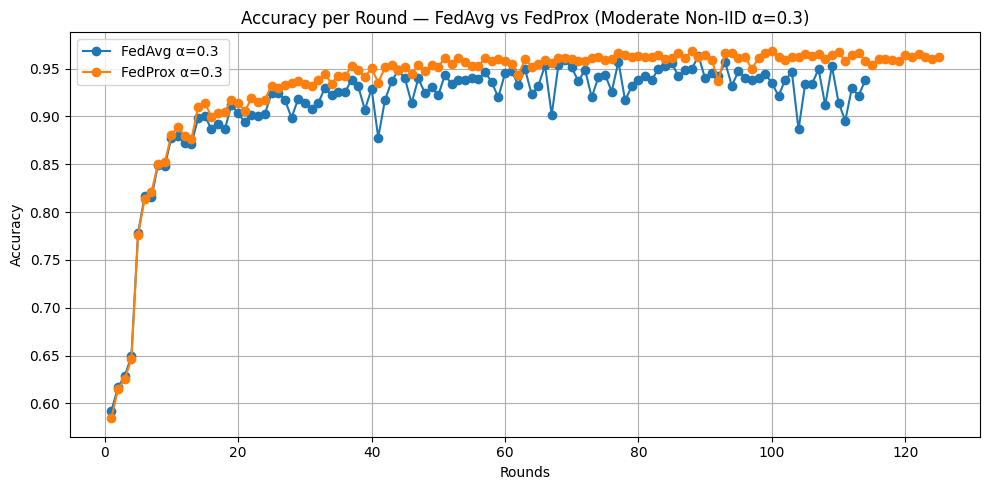

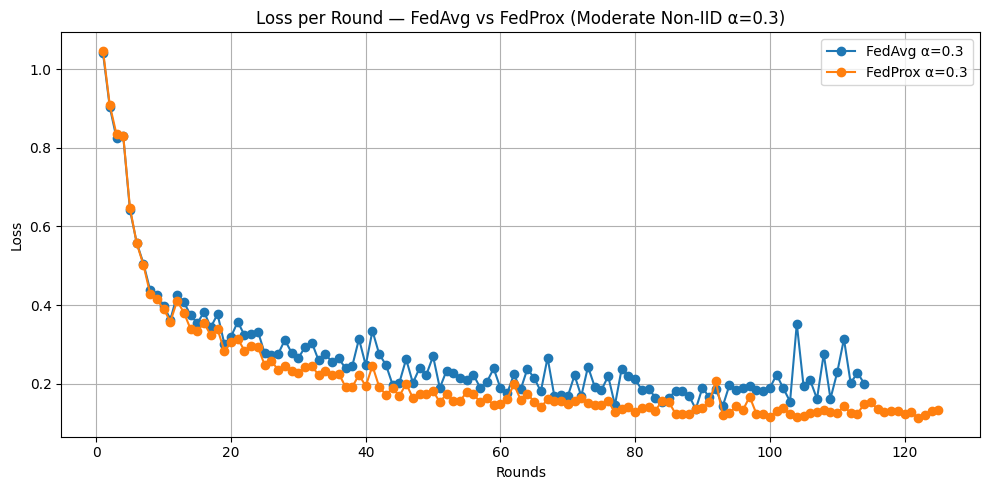

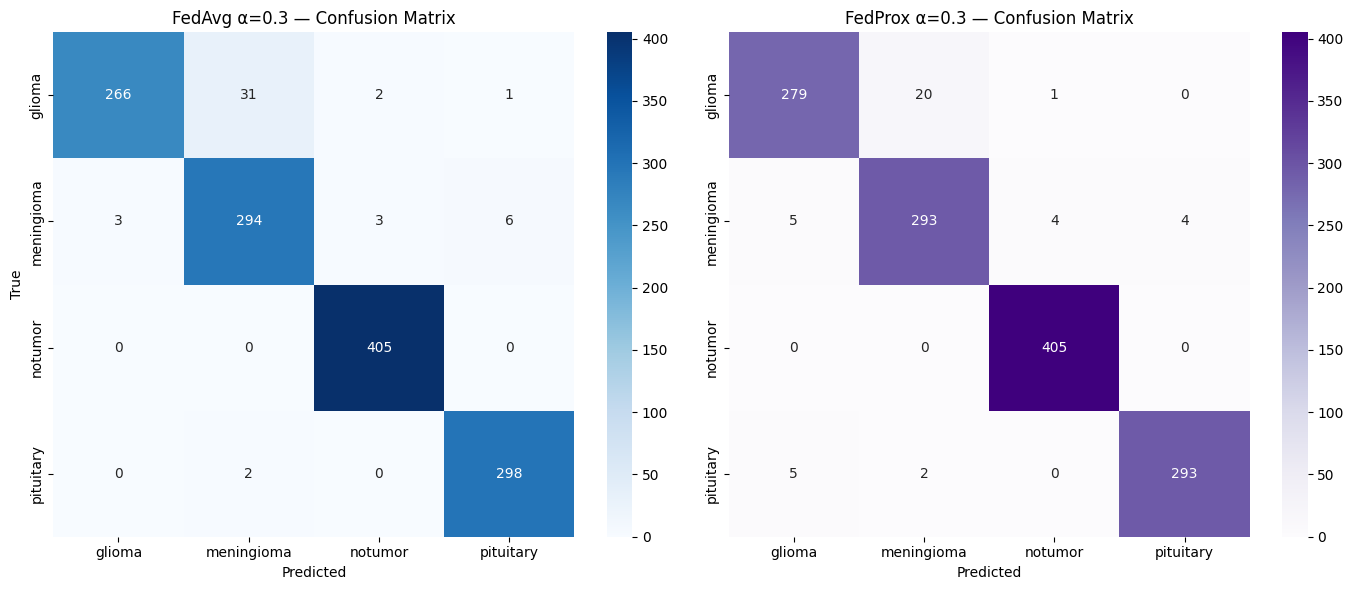

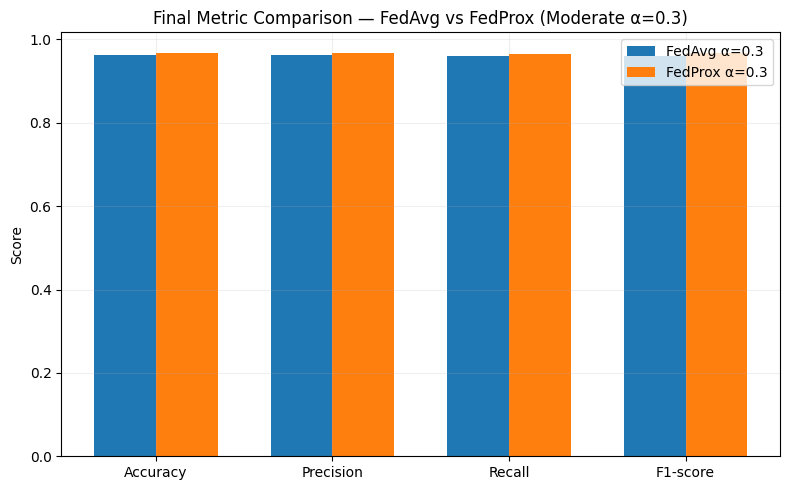

In [15]:
# ============================================================
#   COMPARISON: FEDAVG vs FEDPROX (MODERATE NON-IID α = 0.3)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score
)
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models


# ============================================================
# DEVICE
# ============================================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print("Using:", DEVICE)


# ============================================================
# REBUILD RESNET18 (must match training architecture)
# ============================================================
def create_resnet18_mod_compare(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Frozen layers (same as training)
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters(): p.requires_grad = False
    for p in model.layer1.parameters(): p.requires_grad = False
    for p in model.layer2.parameters(): p.requires_grad = False

    # Trainable deeper layers
    for p in model.layer3.parameters(): p.requires_grad = True
    for p in model.layer4.parameters(): p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


NUM_CLASSES = len(train_dataset.classes)


# ============================================================
# LOAD BOTH TRAINED MODELS
# ============================================================
fedavg_model = create_resnet18_mod_compare(NUM_CLASSES).to(DEVICE)
fedavg_model.load_state_dict(
    torch.load("best_fedavg_moderate_pretrained_alpha3.pth", map_location=DEVICE)
)
fedavg_model.eval()

fedprox_model = create_resnet18_mod_compare(NUM_CLASSES).to(DEVICE)
fedprox_model.load_state_dict(
    torch.load("best_fedprox_moderate_pretrained_alpha3.pth", map_location=DEVICE)
)
fedprox_model.eval()

print("Loaded FedAvg α=0.3 and FedProx α=0.3 models ✔")


# ============================================================
# GLOBAL TEST LOADER
# ============================================================
holdout_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# ============================================================
# GENERIC EVALUATION
# ============================================================
crit = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader):
    preds_all, labels_all = [], []
    total_loss = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = crit(logits, y)

        preds_all.append(logits.argmax(1).cpu())
        labels_all.append(y.cpu())
        total_loss += loss.item() * x.size(0)

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    return {
        "loss": total_loss / len(labels_all),
        "acc": (preds_all == labels_all).mean(),
        "precision": precision_score(labels_all, preds_all, average="macro", zero_division=0),
        "recall": recall_score(labels_all, preds_all, average="macro", zero_division=0),
        "f1": f1_score(labels_all, preds_all, average="macro", zero_division=0),
        "preds": preds_all,
        "labels": labels_all
    }


# ============================================================
# FINAL EVALUATION FOR BOTH
# ============================================================
fa_res = evaluate(fedavg_model, holdout_loader)
fp_res = evaluate(fedprox_model, holdout_loader)

print("\n===== FEDAVG α=0.3 RESULTS =====")
for k, v in fa_res.items():
    if k not in ("preds", "labels"):
        print(f"{k}: {v:.4f}")

print("\n===== FEDPROX α=0.3 RESULTS =====")
for k, v in fp_res.items():
    if k not in ("preds", "labels"):
        print(f"{k}: {v:.4f}")


# ============================================================
# LOAD TRAINING HISTORIES
# ============================================================
fa_hist = np.load("metrics_history_fedavg_moderate_pretrained_alpha3.npy",
                  allow_pickle=True).item()
fp_hist = np.load("metrics_history_fedprox_moderate_pretrained_alpha3.npy",
                  allow_pickle=True).item()

rounds_fa = fa_hist["round"]
rounds_fp = fp_hist["round"]

acc_fa = [m["acc"] for m in fa_hist["holdout"]]
acc_fp = [m["acc"] for m in fp_hist["holdout"]]

loss_fa = [m["loss"] for m in fa_hist["holdout"]]
loss_fp = [m["loss"] for m in fp_hist["holdout"]]


# ============================================================
# ACCURACY CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds_fa, acc_fa, marker="o", label="FedAvg α=0.3")
plt.plot(rounds_fp, acc_fp, marker="o", label="FedProx α=0.3")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Accuracy per Round — FedAvg vs FedProx (Moderate Non-IID α=0.3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# LOSS CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(rounds_fa, loss_fa, marker="o", label="FedAvg α=0.3")
plt.plot(rounds_fp, loss_fp, marker="o", label="FedProx α=0.3")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.title("Loss per Round — FedAvg vs FedProx (Moderate Non-IID α=0.3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# CONFUSION MATRICES
# ============================================================
cm_fa = confusion_matrix(fa_res["labels"], fa_res["preds"])
cm_fp = confusion_matrix(fp_res["labels"], fp_res["preds"])
class_names = train_dataset.classes

fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(cm_fa, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title("FedAvg α=0.3 — Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(cm_fp, annot=True, fmt='d', cmap="Purples",
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title("FedProx α=0.3 — Confusion Matrix")
ax[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()


# ============================================================
# BAR CHART — METRIC COMPARISON
# ============================================================
labels = ["Accuracy", "Precision", "Recall", "F1-score"]
fa_vals = [fa_res["acc"], fa_res["precision"], fa_res["recall"], fa_res["f1"]]
fp_vals = [fp_res["acc"], fp_res["precision"], fp_res["recall"], fp_res["f1"]]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - w/2, fa_vals, w, label="FedAvg α=0.3")
plt.bar(x + w/2, fp_vals, w, label="FedProx α=0.3")
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Final Metric Comparison — FedAvg vs FedProx (Moderate α=0.3)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
